# Discrete Time Quantum Walks

## Ring topology

The choice of a ring is motivated by not knowing how to implement a position "vector" of infinite size. A big enough ring will not struggle too much (200 positions can perfectly simulate 100 steps, so we're cool).

Our first goal is to define the position basis, the $\hat{U}_c$ operator, and the $\hat{S}$ one. 

In [155]:
import numpy as np                          # linear algebra

ring_size = 200

x = np.zeros(ring_size, dtype=np.complex_)  # position vector
x[ring_size//2] = 1

c = np.array([1.0, 0.0], dtype=np.complex_) # coin state

State = np.kron(x, c)                       # generic state: even numbers are tails states, //2 to find position

#Matrix = np.outer(State, State)            Density matrix, we won't use it for now, no need to involve statistics in this bitch

U_coin_H = np.array([[1.0, 1.0],
                   [1.0, -1.0]], dtype=np.complex_)
U_coin_H = 1/np.sqrt(2) * U_coin_H            # Hadamard unitary

Identity_x = np.identity(ring_size)

Coin_H = np.kron(Identity_x, U_coin_H)    # multiplied by the identity over the position base

Tails = np.kron(np.eye(ring_size, k=-1, dtype=np.complex_), ([1, 0], [0, 0]) )
Heads = np.kron(np.eye(ring_size, k=1, dtype=np.complex_), ([0, 0], [0, 1]) )

a = np.zeros((ring_size, ring_size), dtype=np.complex_)
a[ring_size-1, 0] = 1

Tails_boundary = np.kron(a, ([1, 0], [0, 0]) )

b = np.zeros((ring_size, ring_size), dtype=np.complex_)
b[0, ring_size-1] = 1

Heads_boundary = np.kron(b, ([1, 0], [0, 0]) )

Shift = Tails + Heads + Tails_boundary + Heads_boundary # sum of all the shifts caused by heads or tails, plus the boundary conditions to make it an actual ring

Here is an example on how to "read" the state. This will give two values per position: one if the position is x and the coin is heads, and the other if the position is x and the coin is tails.

The absolute value and squaring is to obtain the probability, and not just the vector coefficient.

In [156]:
for i, x in enumerate(State):
    if x != 0:
        print(f"Position: {i//2}, Value: {abs(x)**2}, Coin: {i%2}")

Position: 100, Value: 1.0, Coin: 0


We then implement a step function, which evolves our state by one step; a Measure position function, that puts all the probabilities of finding a walker in a position in a vector; and finally, a step measure of average and standard deviation of the position.

In [157]:
def Step(state, coin_ev):
    state = Shift @ (coin_ev @ state)
    return state

def Measure_pos(state):
    positions = np.zeros(ring_size)

    for i, x in enumerate(state):
        if x != 0:
            positions[i//2] += abs(x)**2

    return positions

def Measure_step(state):
    positions = Measure_pos(state)
    av_pos = 0
    av_pos_sq = 0

    for i, x in enumerate(positions):
        pos = (i-100)
        av_pos += pos * x
        av_pos_sq += pos**2 * x
    
    sigma = np.sqrt(abs(av_pos**2 - av_pos_sq))
    
    return [av_pos, sigma]

We now perform our simulation

In [165]:
x = np.zeros(ring_size, dtype=np.complex_)  # position vector
x[ring_size//2] = 1

c = np.array([1.0, 0.0], dtype=np.complex_) # coin state

State = np.kron(x, c)                       # Re initialize state for new simulation

measures = [Measure_step(State)]

for i in range(100):
    State = Step(State, Coin_H)
    measures.append(Measure_step(State))


final_positions = Measure_pos(State)

And plot our measurements.

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_492710/3035578148.py:17: SyntaxWarning: invalid escape sequence '\s'
  p2.plot(indices, std_devs, label='$\sigma$', linestyle='--', color='red')
/tmp/ipykernel_492710/3035578148.py:18: SyntaxWarning: invalid escape sequence '\s'
  p2.plot(indices, np.sqrt(indices), label='$\sqrt{n}$', linestyle=':', color='black')


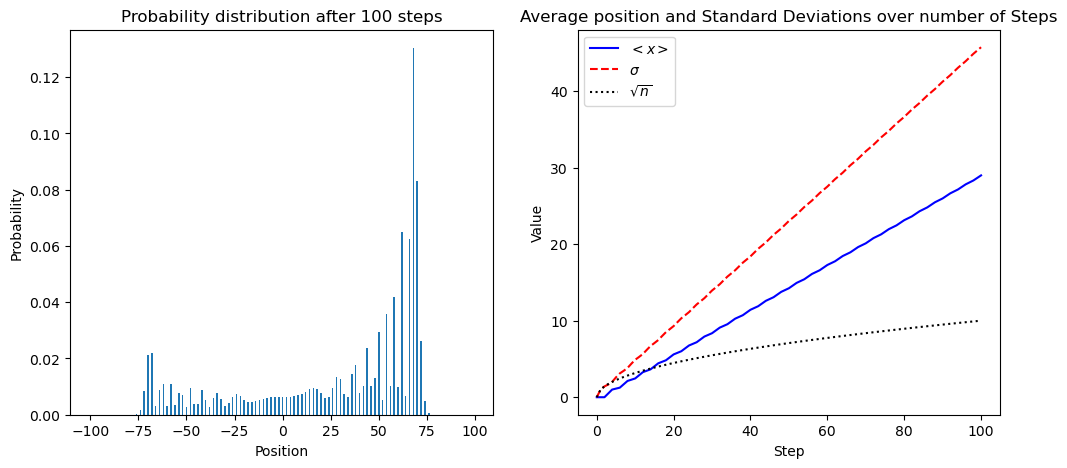

In [159]:
import matplotlib.pyplot as plt

fig, (p1, p2) = plt.subplots(1, 2, figsize=(12, 5))

p1.bar(np.arange(len(final_positions)) - ring_size//2, final_positions)

p1.set_xlabel("Position")
p1.set_ylabel("Probability")
p1.set_title('Probability distribution after 100 steps')

measures_np = np.array(measures)
averages = measures_np[:, 0]
std_devs = measures_np[:, 1]
indices = np.arange(len(measures))

p2.plot(indices, averages, label='$<x>$', linestyle='-', color='blue')
p2.plot(indices, std_devs, label='$\sigma$', linestyle='--', color='red')
p2.plot(indices, np.sqrt(indices), label='$\sqrt{n}$', linestyle=':', color='black')

p2.set_xlabel('Step')
p2.set_ylabel('Value')
p2.set_title('Average position and Standard Deviations over number of Steps')
p2.legend()

These plots are after 100 steps, starting from $\ket{0}\ket{Tails}$.

We note how $\sigma \propto n$ (compared to $\sigma = \sqrt(n)$ in the classic case, plotted here in dotted black), and how, given a starting condition that's not an eigenstate of the coin operator, the average position over time is not 0.

We now perform the same simulation with a different starting state, $\ket{0} \frac{(\ket{Tails} + i\ket{Heads})}{\sqrt(2)}$.

In [160]:
x = np.zeros(ring_size, dtype=np.complex_)  # position vector
x[ring_size//2] = 1

c = np.array([1, 0 + 1j], dtype=np.complex_) # coin state

c = 1/np.sqrt(2) * c

State = np.kron(x, c)                       # Re initialize state for new simulation

measures = [Measure_step(State)]

for i in range(100):
    State = Step(State, Coin_H)
    measures.append(Measure_step(State))


final_positions = Measure_pos(State)

<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_492710/3035578148.py:17: SyntaxWarning: invalid escape sequence '\s'
  p2.plot(indices, std_devs, label='$\sigma$', linestyle='--', color='red')
/tmp/ipykernel_492710/3035578148.py:18: SyntaxWarning: invalid escape sequence '\s'
  p2.plot(indices, np.sqrt(indices), label='$\sqrt{n}$', linestyle=':', color='black')


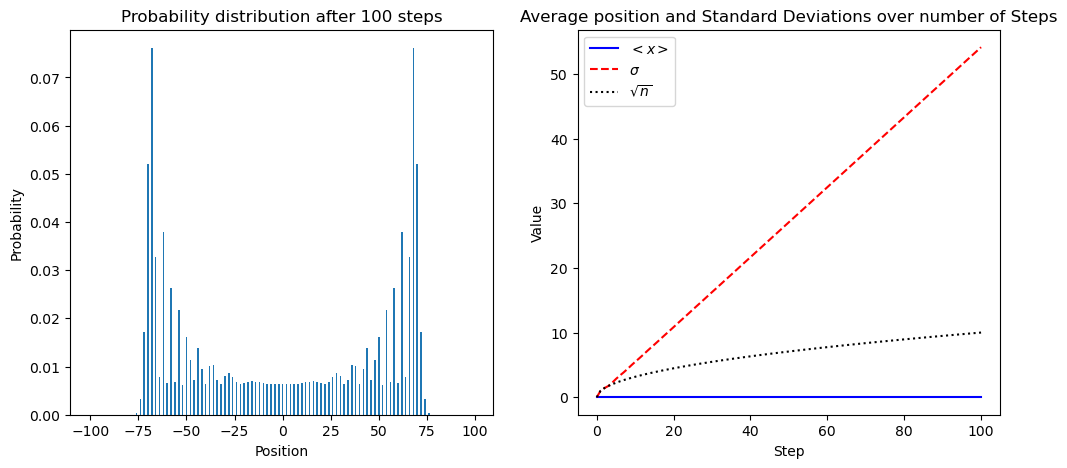

In [161]:
import matplotlib.pyplot as plt

fig, (p1, p2) = plt.subplots(1, 2, figsize=(12, 5))

p1.bar(np.arange(len(final_positions)) - ring_size//2, final_positions)

p1.set_xlabel("Position")
p1.set_ylabel("Probability")
p1.set_title('Probability distribution after 100 steps')

measures_np = np.array(measures)
averages = measures_np[:, 0]
std_devs = measures_np[:, 1]
indices = np.arange(len(measures))

p2.plot(indices, averages, label='$<x>$', linestyle='-', color='blue')
p2.plot(indices, std_devs, label='$\sigma$', linestyle='--', color='red')
p2.plot(indices, np.sqrt(indices), label='$\sqrt{n}$', linestyle=':', color='black')

p2.set_xlabel('Step')
p2.set_ylabel('Value')
p2.set_title('Average position and Standard Deviations over number of Steps')
p2.legend()

Here, the probability distribution after 100 steps is symmetric, and the average position is always 0.

### Fourier basis

We now want to move to the fourier basis, because I kinda need to understand how that works.

$$\ket{\psi_n} = \sum_{m=0}^1 \int_{-\pi}^{\pi} \frac{dk}{2\pi} \psi_n(\tilde{k}, m) \ket{\tilde{k}, m}$$

$$\psi_n(\tilde{k}, m) = \sum_x e^{-ikx} \psi_n(x, m)$$

$$\ket{\tilde{k}, m} = \frac{1}{\sqrt{2N-1}}\sum_x e^{ikx} \ket{x, m}$$

In [162]:
def phi_x(state):                       # Misura del coefficente davanti ad uno stato |x> se faccio la traccia sulla moneta
    positions = np.zeros(ring_size)

    for i, x in enumerate(state):
        if x != 0:
            positions[i//2] += x

    return positions

def fourierprob(k, state):
    fouriertrasf = 0
    phi = phi_x(state)

    for i in range(ring_size):
        fouriertrasf += np.exp((0 - 1j) * k * i) * phi[i]

    return fouriertrasf

/tmp/ipykernel_492710/956793157.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  positions[i//2] += x


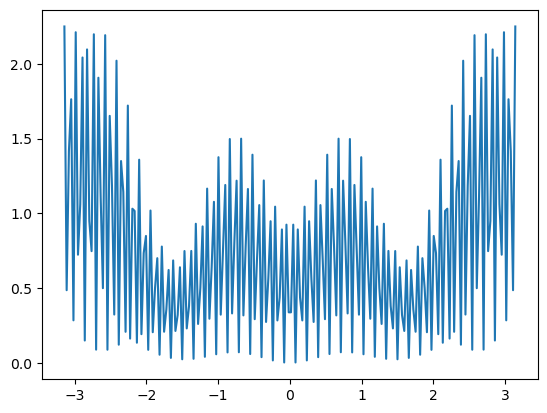

In [192]:
import matplotlib.pyplot as plt

k_val = np.linspace(-np.pi, np.pi, 200)

y = [abs(fourierprob(k, State))**2 for k in k_val]

plt.plot(k_val, y)

In [187]:
x = np.zeros(ring_size, dtype=np.complex_)  # position vector
x[0] = 1/np.sqrt(2)
x[120] = 1/np.sqrt(2)

c = np.array([1, 0 + 1j], dtype=np.complex_) # coin state

c = 1/np.sqrt(2) * c

State = np.kron(x, c)                       # Re initialize state for new simulation

In [191]:
State = Step(State, Coin_H)